In [4]:
import pandas as pd 

In [5]:
import numpy as np 

# Data Lookup  

In [6]:
df = pd.read_csv('./Data/train.csv')

In [7]:
df.shape

(2000, 21)

In [8]:
df.head ()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [9]:
df['price_range'].value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [10]:
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

# SPlitting Data 

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# SPLIT X AND Y 

X = df.drop('price_range', axis=1).values
y = df['price_range'].values

In [13]:
X_train ,X_test, y_train   , y_test = train_test_split(
    X , y , test_size=0.2, random_state=42 , stratify=y
)

In [14]:
# Scaling Data
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()

In [15]:
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

# Training Neuron Network 

In [16]:
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.optim.lr_scheduler as StepLR

In [17]:
# Converting Numpy Matrix toPytorch tensors 
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train,dtype=torch.long)
X_test_tensors = torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensors = torch.tensor(y_test,dtype=torch.long)

In [18]:
# Default Class for Neuron network 

class  MobilePriceNet(nn.Module):
    def __init__(self,input_dim=20,num_classes=4):
        super(MobilePriceNet,self).__init__()
        self.layer1 = nn.Linear(input_dim,128)
        self.bn1 = nn.BatchNorm1d(128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.layer2 = nn.Linear(128,64)
        self.bn2 = nn.BatchNorm1d(64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.layer3 = nn.Linear(64,32)
        self.bn3 = nn.BatchNorm1d(32)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        self.output = nn.Linear(32,num_classes)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.layer1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.layer2(x))))
        x = self.dropout3(self.relu3(self.bn3(self.layer3(x))))
        x = self.output(x)
        return x

In [19]:
model = MobilePriceNet(input_dim=X_train.shape[1], num_classes=4)

In [20]:
# ERROR Calc + Adam + StepLrScheduler  

criteria = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters() , lr=0.01)



In [21]:
# Drop learning rate by 50% every 30 epochs
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Training Epochs

In [22]:
epochs = 100
train_Losses= []

In [23]:
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad() # Clear old gradients

    # Forward Pass
    outputs = model(X_train_tensor)
    loss = criteria(outputs,y_train_tensor)

    # Backward Pass 
    loss.backward()
    optimizer.step()

    # Step  the scheduler 
    scheduler.step()

    train_Losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

Epoch [10/100], Loss: 0.7539, LR: 0.010000
Epoch [20/100], Loss: 0.4046, LR: 0.010000
Epoch [30/100], Loss: 0.2727, LR: 0.005000
Epoch [40/100], Loss: 0.2292, LR: 0.005000
Epoch [50/100], Loss: 0.2030, LR: 0.005000
Epoch [60/100], Loss: 0.1821, LR: 0.002500
Epoch [70/100], Loss: 0.1569, LR: 0.002500
Epoch [80/100], Loss: 0.1709, LR: 0.002500
Epoch [90/100], Loss: 0.1395, LR: 0.001250
Epoch [100/100], Loss: 0.1260, LR: 0.001250


# Evaluating The model 

In [24]:
from sklearn.metrics import accuracy_score, classification_report

In [25]:
model.eval()
with torch.no_grad(): # Turn off gradient tracking for testing
    test_outputs = model(X_test_tensors)
    # Get the index of the max log-probability (the predicted class)
    _, predicted = torch.max(test_outputs, 1)
    
    acc = accuracy_score(y_test_tensors.numpy(), predicted.numpy())
    print(f"\nFinal Test Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test_tensors.numpy(), predicted.numpy()))


Final Test Accuracy: 0.9425

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       100
           1       0.91      0.94      0.93       100
           2       0.94      0.91      0.92       100
           3       0.95      0.97      0.96       100

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



# Plot The  Error Graph 

In [26]:
import matplotlib.pyplot as plt

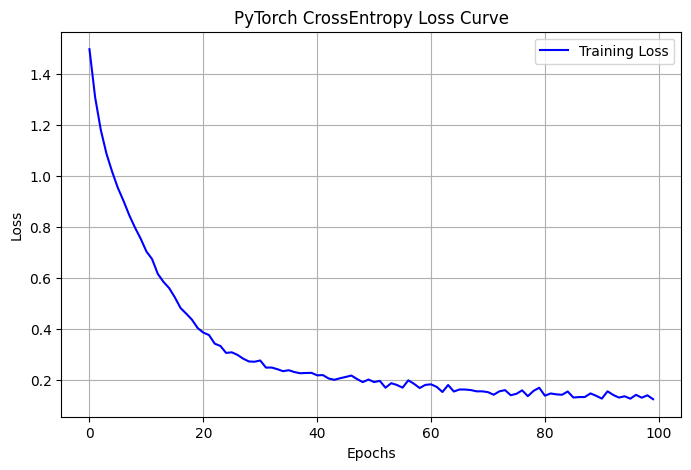

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(train_Losses, label='Training Loss', color='blue')
plt.title('PyTorch CrossEntropy Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
learning_rates = [0.01, 0.001, 0.0001]
epochs = 100

for lr in learning_rates:
    print(f"\n--- Starting run with learning rate: {lr} ---")
    
    # 1. You MUST re-initialize the model to reset weights for each run!
    model = MobilePriceNet(input_dim=X_train.shape[1], num_classes=4)
    
    # 2. Setup optimizer with the current lr
    criteria = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    
    train_Losses = []
    epoch_losses = []  # reset before each run
    # 3. Training Loop
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train_tensor)
        loss = criteria(outputs, y_train_tensor)
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        epoch_losses.append(loss.item())
        train_Losses.append(loss.item())

    # 4. Evaluation
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensors)
        _, predicted = torch.max(test_outputs, 1)
        acc = accuracy_score(y_test_tensors.numpy(), predicted.numpy())

    log_experiment(
    lr=lr,
    batch_size=32,
    epochs=50,
    epoch_losses=epoch_losses,  # you need to collect this during training
    final_accuracy=acc
)
    print(f"Finished lr={lr} | Final Test Accuracy: {acc:.4f}")
    show_comparison()
    # Good luck comparing the train_Losses arrays for all 3 runs!


--- Starting run with learning rate: 0.01 ---
Finished lr=0.01 | Final Test Accuracy: 0.9350
    time   lr  batch_size  epochs  final_accuracy
15:44:37 0.01          32      50           0.935

--- Starting run with learning rate: 0.001 ---
Finished lr=0.001 | Final Test Accuracy: 0.8250
    time    lr  batch_size  epochs  final_accuracy
15:44:37 0.010          32      50           0.935
15:44:42 0.001          32      50           0.825

--- Starting run with learning rate: 0.0001 ---
Finished lr=0.0001 | Final Test Accuracy: 0.3850
    time     lr  batch_size  epochs  final_accuracy
15:44:37 0.0100          32      50           0.935
15:44:42 0.0010          32      50           0.825
15:44:49 0.0001          32      50           0.385


# Manual experiment tracker — plain Python dict

In [29]:
import pandas as pd
from datetime import datetime

In [30]:
experiments = []


In [31]:
def log_experiment(lr, batch_size, epochs, epoch_losses, final_accuracy):
    # Store everything about this run in one dict
    experiments.append({
        'timestamp': datetime.now().strftime('%H:%M:%S'),  # when did we run this?
        'lr': lr,                          # what learning rate?
        'batch_size': batch_size,          # what batch size?
        'epochs': epochs,                  # how many epochs?
        'epoch_losses': epoch_losses,      # loss at EVERY epoch — not just final
        'final_accuracy': final_accuracy   # final result
    })

In [32]:
def show_comparison():
    rows = []
    for exp in experiments:
        rows.append({
            'time': exp['timestamp'],
            'lr': exp['lr'],
            'batch_size': exp['batch_size'],
            'epochs': exp['epochs'],
            'final_accuracy': exp['final_accuracy']
        })
    print(pd.DataFrame(rows).to_string(index=False))

# Mlflow

In [36]:
import mlflow
import mlflow.pytorch

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [39]:
mlflow.set_experiment("mobile-price-lr-comparison")
# Start the MLflow tracking server (local)
# This replaces your 'experiments = []' list

<Experiment: artifact_location='/home/spectra/Desktop/ml-ai-journey/Week-6/mlruns/1', creation_time=1775643538495, experiment_id='1', last_update_time=1775643538495, lifecycle_stage='active', name='mobile-price-lr-comparison', tags={}, trace_location=None, workspace='default'>

In [46]:
for lr in [0.01, 0.001, 0.0001]:
    
    # One 'run' = one experiment entry
    # Replaces previous experiments.append({...})
    with mlflow.start_run(run_name=f"lr={lr}"):

        # Log hyperparameters — replaces 'lr': lr, 'batch_size': 32 in your dict
        mlflow.log_param("lr", lr)
        mlflow.log_param("batch_size", 32)
        mlflow.log_param("epochs", 50)

        epoch_losses = []
        
        print(f"\n--- Starting run with learning rate: {lr} ---")
    
        # 1. You MUST re-initialize the model to reset weights for each run!
        model = MobilePriceNet(input_dim=X_train.shape[1], num_classes=4)
        
        # 2. Setup optimizer with the current lr
        criteria = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
        
        train_Losses = []
    
        # 3. Training Loop
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            
            outputs = model(X_train_tensor)
            loss = criteria(outputs, y_train_tensor)
            
            loss.backward()
            optimizer.step()
            scheduler.step()
            epoch_losses.append(loss.item())
            train_Losses.append(loss.item())
            mlflow.log_metric("loss", loss.item(), step=epoch)
    
        # 4. Evaluation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensors)
            _, predicted = torch.max(test_outputs, 1)
            acc = accuracy_score(y_test_tensors.numpy(), predicted.numpy())
            mlflow.log_metric("accuracy", acc, step=epoch)

       
    
        
        
        
        print(f"lr={lr} | accuracy={acc:.4f}")

        if lr == 0.01:
            mlflow.pytorch.log_model(model, "mobile-price-model")
            print("--> Model artifacts saved to MLflow for lr=0.01")


--- Starting run with learning rate: 0.01 ---


2026/04/09 13:18:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 13:18:28 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


lr=0.01 | accuracy=0.9375
--> Model artifacts saved to MLflow for lr=0.01

--- Starting run with learning rate: 0.001 ---
lr=0.001 | accuracy=0.8275

--- Starting run with learning rate: 0.0001 ---
lr=0.0001 | accuracy=0.2600


## Summary

**What I built:** Manual experiment tracker in Python, then rebuilt 
using MLflow — logged 3 runs with different learning rates.

**The problem without tracking:**
- Results disappear when notebook closes
- No reproducibility — can't recreate exact config
- No comparison across runs

**MLflow concepts:**
- mlflow.set_experiment() — creates experiment group
- mlflow.start_run() — one run = one experiment entry
- mlflow.log_param() — hyperparameters (lr, batch_size, epochs)
- mlflow.log_metric(name, value, step=epoch) — metrics per epoch
- step=epoch — maps value to x-axis, enables curves not dots
- mlruns/ folder — where everything is stored locally
- mlflow ui — launches browser UI at localhost:5000

**Key insight:** log_metric inside the loop = curve. 
Outside the loop = single dot. The curve tells you 
WHY a run succeeded or failed, not just the final number.
lr=0.0001 wasn't a bad lr — it just needed more epochs.
The loss curve proved it was still learning at epoch 50.

**Next:** MLflow model registry — Day 44

# Loading model from model registry 

In [47]:
import mlflow.pytorch

# Load model by name and stage — no file paths, no pkl files
# MLflow finds the right version automatically
model_uri = "models:/mobile-price-classifier/Production"
loaded_model = mlflow.pytorch.load_model(model_uri)

print("Model loaded from registry")
print(type(loaded_model))

# Run a prediction
loaded_model.eval()
with torch.no_grad():
    test_output = loaded_model(X_test_tensors[:5])
    _, predicted = torch.max(test_output, 1)
    print(f"Predictions: {predicted}")
    print(f"Actual:      {y_test_tensors[:5]}")

Model loaded from registry
<class '__main__.MobilePriceNet'>
Predictions: tensor([3, 1, 0, 2, 3])
Actual:      tensor([3, 1, 0, 2, 3])


# Register a second version

In [48]:
# Simulate a better model — train with best config + more epochs
with mlflow.start_run(run_name="lr=0.01-improved"):
    mlflow.log_param("lr", 0.01)
    mlflow.log_param("batch_size", 32)
    mlflow.log_param("epochs", 100)  # more epochs than before
    
    model_v2 = MobilePriceNet(input_dim=X_train.shape[1], num_classes=4)
    optimizer = torch.optim.Adam(model_v2.parameters(), lr=0.01)
    criteria = nn.CrossEntropyLoss()
    
    for epoch in range(100):
        model_v2.train()
        optimizer.zero_grad()
        outputs = model_v2(X_train_tensor)
        loss = criteria(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        mlflow.log_metric("loss", loss.item(), step=epoch)
    
    model_v2.eval()
    with torch.no_grad():
        test_outputs = model_v2(X_test_tensors)
        _, predicted = torch.max(test_outputs, 1)
        acc = accuracy_score(y_test_tensors.numpy(), predicted.numpy())
    
    mlflow.log_metric("accuracy", acc)
    mlflow.pytorch.log_model(model_v2, "mobile-price-model",
                             registered_model_name="mobile-price-classifier")
    
    print(f"V2 accuracy: {acc:.4f}")

2026/04/09 16:51:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 16:51:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


V2 accuracy: 0.9275


Registered model 'mobile-price-classifier' already exists. Creating a new version of this model...
Created version '3' of model 'mobile-price-classifier'.


In [49]:
model_uri = "models:/mobile-price-classifier/Production"
loaded_model = mlflow.pytorch.load_model(model_uri)

loaded_model.eval()
with torch.no_grad():
    test_output = loaded_model(X_test_tensors[:5])
    _, predicted = torch.max(test_output, 1)
    print(f"Predictions: {predicted}")
    print(f"Actual:      {y_test_tensors[:5]}")

Predictions: tensor([3, 1, 0, 2, 3])
Actual:      tensor([3, 1, 0, 2, 3])


## Summary

**What I built:** MLflow model registry — registered, versioned, 
and promoted models through Staging → Production.

**Key concepts:**
- log_model() — stores actual model weights + environment files
- Model Registry — central store for all model versions
- Stages: None → Staging → Production → Archived
- models:/name/Stage URI — load by stage not file path

**The three files MLflow stores with every model:**
- conda.yaml — exact conda environment
- python_env.yaml — Python version
- requirements.txt — pip dependencies

**Why registry beats pkl files:**
- No file path hardcoding in API code
- Promote new version = zero code changes
- Full rollback in two clicks
- Complete audit trail — who promoted what and when

**Production workflow:**
1. Train new model → log_model() → Version N created
2. Transition to Staging → run integration tests
3. Transition to Production → old version auto-archived
4. API picks up new model automatically

**Key insight:** Decoupling model versioning from code deployment
is what makes ML systems maintainable at scale. Your API never 
changes — only the model behind it does.

**Next:** Prometheus monitoring — Day 45